# ST2195 Programming for Data Science
## Coursework 2 – 2009 ASA Flight Data Analysis (2004–2008)

This notebook answers all three questions using US domestic flight data from 2004 to 2008.  
All data files should be placed in a **`data/` subfolder** within the same directory as this notebook.  
All paths are built relative to the notebook location.

---

### Questions

- **Question A** – What are the best times and days of the week to minimise delays each year?
- **Question B** – Do older planes suffer more delays on a year-to-year basis?
- **Question C** – Fit a logistic regression model for the probability of diverted flights and visualise how the coefficients change across years.

---

### Data Files Required

| File | Description |
|---|---|
| `2004.csv` to `2008.csv` | Flight records for each year |
| `airports.csv` | Airport IATA codes with state, latitude and longitude |
| `plane-data.csv` | Aircraft tail numbers with manufacture year |
| `carriers.csv` | IATA carrier codes mapped to full airline names |
| `data/shapefiles/cb_2024_us_state_500k.shp` | US state shapefile for Question C maps |

---

### Memory Strategy

The five-year dataset contains approximately 31 million rows.  
Each year file is read in **chunks of 200,000 rows** to avoid loading everything into memory at once.  
Only the columns needed for each question are read, and results are aggregated before raw data is discarded.


## 1. Setup

Imports all required libraries, sets global constants, and defines paths relative to the notebook location.

### Constants

| Constant | Default | Purpose |
|---|---|---|
| `CHUNK_SIZE` | 200,000 | Rows read per chunk |
| `SAMPLE_SIZE` | 5,000,000 | Max flights sampled per year in Part C |
| `TRAIN_YEARS` | 2004–2007 | Years used to train the prediction model |
| `TEST_YEAR` | 2008 | Year held out for testing the prediction model |


In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import gc
import warnings
warnings.filterwarnings('ignore')
import geopandas as gpd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, roc_curve,
    f1_score, precision_score, recall_score
)

# Paths — all relative to the notebook location
BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, 'data')

# Constants
YEARS       = [2004, 2005, 2006, 2007, 2008]
TRAIN_YEARS = [2004, 2005, 2006, 2007]
TEST_YEAR   = 2008
CHUNK_SIZE  = 200_000
SAMPLE_SIZE = 5_000_000

day_labels = {
    1: 'Monday', 2: 'Tuesday', 3: 'Wednesday',
    4: 'Thursday', 5: 'Friday', 6: 'Saturday', 7: 'Sunday'
}
day_labels_short = {
    1: 'Mon', 2: 'Tue', 3: 'Wed',
    4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'
}

# Strict colour order for line graphs: Red, Blue, Yellow, Green, Purple, Pink, Brown, Black
STRICT_COLORS = [
    '#E53935', '#1565C0', '#F9A825', '#2E7D32',
    '#6A1B9A', '#E91E63', '#795548', '#212121'
]


## 2. Load Supplementary Lookup Tables

Three supplementary files are loaded here and kept in memory for the entire notebook:

**airports.csv** – Contains one row per airport with its IATA code, US state, latitude and longitude.  
This is used in Part C to add geographic coordinates and state labels to each flight record.

**plane-data.csv** – Contains one row per registered aircraft with its tail number and manufacture year.  
This is used in Parts B and C to calculate how old each plane was at the time of the flight.

**carriers.csv** – Contains one row per airline carrier with its IATA code and full airline name.  
This is used in Part C to map carrier codes to readable airline names in the diversion rate table.

All three files are small enough to load fully into memory. airports.csv and plane-data.csv  
are indexed by their key column so they can be used for fast `.map()` lookups rather than  
expensive merge operations inside the chunked loop.

Where a plane's manufacture year is missing (the tail number is not found in the lookup),  
the **median manufacture year** across all known planes is used as a substitute.  
This is a simple imputation strategy that avoids dropping flights with unknown aircraft.


In [98]:
# airports.csv — iata, state, lat, long
airports_raw = pd.read_csv(os.path.join(DATA_DIR, 'airports.csv'), low_memory=False)
airports_raw = airports_raw[['iata','state','lat','long']].dropna(subset=['iata'])
airports_raw['state'] = airports_raw['state'].fillna('Unknown')
airports_raw['lat']   = pd.to_numeric(airports_raw['lat'],  errors='coerce')
airports_raw['long']  = pd.to_numeric(airports_raw['long'], errors='coerce')

mean_lat = float(airports_raw['lat'].mean())
mean_lon = float(airports_raw['long'].mean())

airport_idx  = airports_raw.set_index('iata')
origin_state = airport_idx['state']
origin_lat   = airport_idx['lat']
origin_lon   = airport_idx['long']
dest_state   = airport_idx['state']
dest_lat     = airport_idx['lat']
dest_lon     = airport_idx['long']

# plane-data.csv — tailnum, manufacture year
planes = pd.read_csv(os.path.join(DATA_DIR, 'plane-data.csv'), low_memory=False)
planes = planes[['tailnum','year']].rename(columns={'tailnum': 'TailNum', 'year': 'MfgYear'})
planes['MfgYear'] = pd.to_numeric(planes['MfgYear'], errors='coerce')
plane_lookup      = planes.set_index('TailNum')['MfgYear']
global_mfg_median = float(planes['MfgYear'].median())


# carriers.csv — IATA code → full airline name
carriers_raw  = pd.read_csv(os.path.join(DATA_DIR, 'carriers.csv'))
carriers_raw.columns = carriers_raw.columns.str.strip()
code_col = [c for c in carriers_raw.columns if 'code' in c.lower()][0]
name_col = [c for c in carriers_raw.columns if 'code' not in c.lower()][0]
carrier_name_map = carriers_raw.set_index(code_col)[name_col].str.strip()
del carriers_raw
del airports_raw, airport_idx, planes
gc.collect()


28

## 3. Shared Feature Engineering Functions

These two functions are used by Question C. They are defined here once and reused.

### `engineer_chunk(chunk, flight_year)`

Takes a single chunk of raw flight data (a DataFrame with up to `CHUNK_SIZE` rows) and adds all the  
engineered features needed by the logistic regression model:

- **DepHour / ArrHour** – The scheduled departure and arrival hour (0–23), extracted from the 4-digit `CRSDepTime`  
  and `CRSArrTime` columns. For example, a value of `1435` becomes hour `14`.
- **Distance** – Converted to numeric and zero-filled for any missing values.
- **Origin_State, Origin_Lat, Origin_Lon** – Airport state and coordinates mapped from `airports.csv` using the  
  origin airport IATA code. Unmatched codes receive the mean coordinates.
- **Dest_State, Dest_Lat, Dest_Lon** – Same as above for the destination airport.
- **PlaneAge** – The age of the aircraft at the time of the flight, calculated as `flight_year − MfgYear`.  
  Negative values (data errors) are clipped to 0.

### `load_year_sampled_c(year, target_size)`

Reads a full year CSV file in chunks, applies `engineer_chunk` to each, and returns a **stratified sample**  
of up to `target_size` rows. The stratification works as follows:

1. All diverted flights (`Diverted == 1`) in the year are kept in full, regardless of how many there are.
2. A random sample of non-diverted flights is drawn to fill the remainder of `target_size`.
3. The resulting sample is shuffled so diverted and non-diverted rows are interleaved.

This is necessary because diversions make up less than 0.3% of all flights. Without this stratification,  
the model would rarely see any diverted examples and would learn to predict 'not diverted' for everything.

### Feature exclusion: WeatherDelay

`WeatherDelay` is **not included** as a feature, even though it is a plausible cause of diversions.  
The reason is that `WeatherDelay` is a post-flight recorded field — it is only populated after a flight  
has landed. For diverted flights, this field is almost always missing. Including it would cause the model  
to learn a pattern from the absence of data rather than from genuine flight characteristics.  
This is known as **data leakage** and would produce misleadingly high accuracy.

In [99]:
# Feature lists for Question C
numeric_features_c = [
    'Distance', 'PlaneAge',
    'Month', 'DayofMonth', 'DayOfWeek',
    'DepHour', 'ArrHour',
    'Origin_Lat', 'Origin_Lon',
    'Dest_Lat',   'Dest_Lon'
]
cat_features_c = ['UniqueCarrier', 'Origin_State', 'Dest_State']
all_features_c = numeric_features_c + cat_features_c

cols_needed_c = [
    'Month', 'DayofMonth', 'DayOfWeek',
    'CRSDepTime', 'CRSArrTime',
    'UniqueCarrier', 'TailNum',
    'Origin', 'Dest', 'Distance', 'Diverted'
]


def engineer_chunk(chunk, flight_year):
    """Add all model features to a raw chunk of flight data."""
    c = chunk.copy()
    c = c.dropna(subset=['Diverted'])
    if len(c) == 0:
        return None
    c['Diverted'] = c['Diverted'].astype(np.int8)
    c['DepHour']  = (c['CRSDepTime'].fillna(0).astype(int) // 100) % 24
    c['ArrHour']  = (c['CRSArrTime'].fillna(0).astype(int) // 100) % 24
    c['Distance'] = pd.to_numeric(c['Distance'], errors='coerce').fillna(0).astype(np.float32)
    c['Origin_State'] = c['Origin'].map(origin_state).fillna('Unknown')
    c['Origin_Lat']   = c['Origin'].map(origin_lat).fillna(mean_lat).astype(np.float32)
    c['Origin_Lon']   = c['Origin'].map(origin_lon).fillna(mean_lon).astype(np.float32)
    c['Dest_State'] = c['Dest'].map(dest_state).fillna('Unknown')
    c['Dest_Lat']   = c['Dest'].map(dest_lat).fillna(mean_lat).astype(np.float32)
    c['Dest_Lon']   = c['Dest'].map(dest_lon).fillna(mean_lon).astype(np.float32)
    c['MfgYear']  = c['TailNum'].map(plane_lookup).fillna(global_mfg_median)
    c['PlaneAge'] = (flight_year - c['MfgYear']).clip(lower=0).astype(np.float32)
    for col in ['Month', 'DayofMonth', 'DayOfWeek', 'DepHour', 'ArrHour']:
        c[col] = pd.to_numeric(c[col], errors='coerce').fillna(0).astype(np.int8)
    return c[all_features_c + ['Diverted']]


def load_year_sampled_c(year, target_size=None):
    """Read one year's CSV in chunks and return a stratified sample (all diversions kept)."""
    if target_size is None:
        target_size = SAMPLE_SIZE
    path = os.path.join(DATA_DIR, f'{year}.csv')
    div_chunks, non_div_chunks = [], []
    reader = pd.read_csv(
        path, usecols=cols_needed_c,
        chunksize=CHUNK_SIZE, low_memory=False, on_bad_lines='skip'
    )
    for chunk in reader:
        eng = engineer_chunk(chunk, year)
        del chunk
        if eng is None:
            continue
        div_chunks.append(eng[eng['Diverted'] == 1])
        non_div_chunks.append(eng[eng['Diverted'] == 0])
        del eng
        gc.collect()
    if not div_chunks:
        return None
    all_div     = pd.concat(div_chunks,     ignore_index=True)
    all_non_div = pd.concat(non_div_chunks, ignore_index=True)
    del div_chunks, non_div_chunks
    gc.collect()
    n_div    = len(all_div)
    n_sample = min(target_size - n_div, len(all_non_div))
    sample   = pd.concat(
        [all_div, all_non_div.sample(n=n_sample, random_state=42)]
    ).sample(frac=1, random_state=42)
    del all_div, all_non_div
    gc.collect()
    return sample


def make_preprocessor():
    """ColumnTransformer: OneHotEncoder for categoricals + StandardScaler for numerics."""
    return ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features_c),
        ('num', StandardScaler(), numeric_features_c)
    ], remainder='drop')


def make_logreg():
    """Logistic regression with balanced class weights to handle rare diversions."""
    return LogisticRegression(
        max_iter=2000, tol=1e-3,
        class_weight='balanced',
        solver='liblinear', C=1.0, random_state=42
    )


---
## 4. Question A – Best Times and Days to Minimise Delays

### Research Question
What combination of day of the week and hour of the day gives the lowest average arrival delay,  
and does this pattern change year to year from 2004 to 2008?

### Approach

**Why arrival delay?**  
Arrival delay measures the passenger experience more directly than departure delay.  
A negative arrival delay means the flight arrived early.

**Why group by scheduled departure hour?**  
Delays accumulate across the day. A flight that departs at 06:00 faces an uncongested system,  
while a flight at 19:00 is affected by everything that went wrong since the morning.  
Grouping by departure hour captures this daily accumulation effect.

**Data processing steps:**
1. Read each year's CSV in chunks of `CHUNK_SIZE` rows.
2. Drop cancelled flights — these have no arrival delay and would distort the average.
3. Extract the departure hour from the 4-digit `CRSDepTime` column.
4. Group by `(DayOfWeek, DepHour)` and compute the mean `ArrDelay` for each combination.
5. Aggregate results across all chunks for the year.
6. Record the best (lowest average delay) and worst (highest average delay) slot.

Only three columns are read from each file — `DayOfWeek`, `CRSDepTime`, `ArrDelay`, and `Cancelled` —  
to minimise memory use.

In [100]:
cols_needed_a = ['DayOfWeek', 'CRSDepTime', 'ArrDelay', 'Cancelled']

yearly_agg   = {}
yearly_day   = {}
yearly_hour  = {}
summary_rows = []

for y in YEARS:
    path   = os.path.join(DATA_DIR, f'{y}.csv')
    chunks = []
    reader = pd.read_csv(
        path, usecols=cols_needed_a,
        chunksize=CHUNK_SIZE, low_memory=False, on_bad_lines='skip'
    )
    for chunk in reader:
        c = chunk[chunk['Cancelled'] != 1].copy()
        del chunk
        c = c.dropna(subset=['ArrDelay'])
        c['DepHour']  = (c['CRSDepTime'].fillna(0).astype(int) // 100) % 24
        c['ArrDelay'] = pd.to_numeric(c['ArrDelay'], errors='coerce')
        c = c.dropna(subset=['ArrDelay'])
        chunks.append(c[['DayOfWeek', 'DepHour', 'ArrDelay']])
        del c
        gc.collect()
    if not chunks:
        continue
    year_df = pd.concat(chunks, ignore_index=True)
    del chunks
    gc.collect()

    heatmap = (
        year_df.groupby(['DayOfWeek', 'DepHour'])['ArrDelay']
        .agg(AvgDelay='mean', FlightCount='count').reset_index()
    )
    yearly_agg[y] = heatmap

    day_agg = (
        year_df.groupby('DayOfWeek')['ArrDelay']
        .agg(AvgDelay='mean', FlightCount='count').reset_index()
    )
    day_agg['DayName'] = day_agg['DayOfWeek'].map(day_labels)
    yearly_day[y] = day_agg

    hour_agg = (
        year_df.groupby('DepHour')['ArrDelay']
        .agg(AvgDelay='mean', FlightCount='count').reset_index()
    )
    yearly_hour[y] = hour_agg

    best  = heatmap.loc[heatmap['AvgDelay'].idxmin()]
    worst = heatmap.loc[heatmap['AvgDelay'].idxmax()]
    summary_rows.append({
        'Year':                  y,
        'Best Day':              day_labels[int(best['DayOfWeek'])],
        'Best Hour':             f"{int(best['DepHour']):02d}:00",
        'Best Avg Delay (min)':  round(best['AvgDelay'], 2),
        'Worst Day':             day_labels[int(worst['DayOfWeek'])],
        'Worst Hour':            f"{int(worst['DepHour']):02d}:00",
        'Worst Avg Delay (min)': round(worst['AvgDelay'], 2)
    })
    del year_df
    gc.collect()

summary_df_a = pd.DataFrame(summary_rows)
print('Question A – Best/Worst Departure Slots per Year')
display(summary_df_a.set_index('Year'))


Question A – Best/Worst Departure Slots per Year


,Best Day,Best Hour,Best Avg Delay (min),Worst Day,Worst Hour,Worst Avg Delay (min)
Year,,,,,,
2004,Sunday,03:00,-9.73,Monday,03:00,18.80
2005,Wednesday,03:00,-2.58,Friday,04:00,40.08
2006,Thursday,04:00,-4.62,Friday,03:00,42.44
2007,Wednesday,03:00,-2.70,Thursday,20:00,24.26
2008,Tuesday,04:00,-8.09,Friday,20:00,23.44


### Question A – Plots

**Figure 1 (Primary):** A grid of heatmaps, one panel per year. Each cell represents the average arrival delay  
for a specific day-of-week and departure-hour combination. Green = low delay, Red = high delay.  
The white star marks the single best slot for that year. The colour scale is shared across all five panels  
so delays can be compared directly between years.

**Figure 2 (Supplementary):** Bar charts showing average delay broken down by day only and by hour only,  
one row per year. The green bar in each chart marks the lowest-delay option for that breakdown and year.

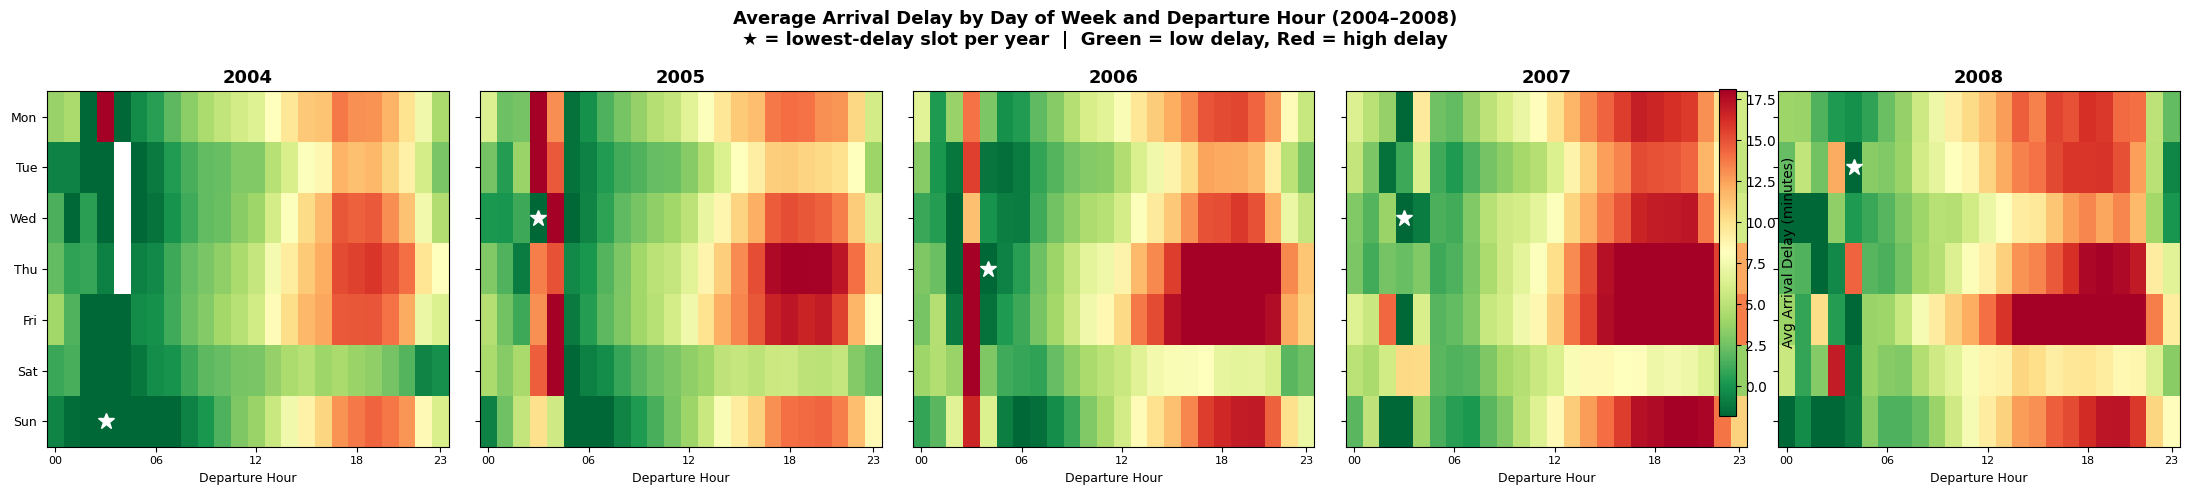

In [101]:
fig, axes = plt.subplots(1, len(YEARS), figsize=(22, 5), sharey=True)

all_delays = np.concatenate([yearly_agg[y]['AvgDelay'].values for y in YEARS])
vmin = np.percentile(all_delays, 5)
vmax = np.percentile(all_delays, 95)

for ax, y in zip(axes, YEARS):
    hm     = yearly_agg[y].copy()
    matrix = np.full((7, 24), np.nan)
    for _, row in hm.iterrows():
        d = int(row['DayOfWeek']) - 1
        h = int(row['DepHour'])
        if 0 <= d < 7 and 0 <= h < 24:
            matrix[d, h] = row['AvgDelay']
    im = ax.imshow(matrix, aspect='auto', cmap='RdYlGn_r', vmin=vmin, vmax=vmax)
    best_row = hm.loc[hm['AvgDelay'].idxmin()]
    ax.plot(int(best_row['DepHour']), int(best_row['DayOfWeek']) - 1,
            'w*', markersize=12, zorder=5)
    ax.set_title(str(y), fontsize=13, fontweight='bold')
    ax.set_xlabel('Departure Hour', fontsize=9)
    ax.set_xticks([0, 6, 12, 18, 23])
    ax.set_xticklabels(['00', '06', '12', '18', '23'], fontsize=8)
    if ax == axes[0]:
        ax.set_yticks(range(7))
        ax.set_yticklabels(list(day_labels_short.values()), fontsize=9)

cbar = fig.colorbar(im, ax=axes, orientation='vertical', shrink=0.85, pad=0.01)
cbar.set_label('Avg Arrival Delay (minutes)', fontsize=10)
fig.suptitle(
    'Average Arrival Delay by Day of Week and Departure Hour (2004–2008)\n'
    '★ = lowest-delay slot per year  |  Green = low delay, Red = high delay',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()


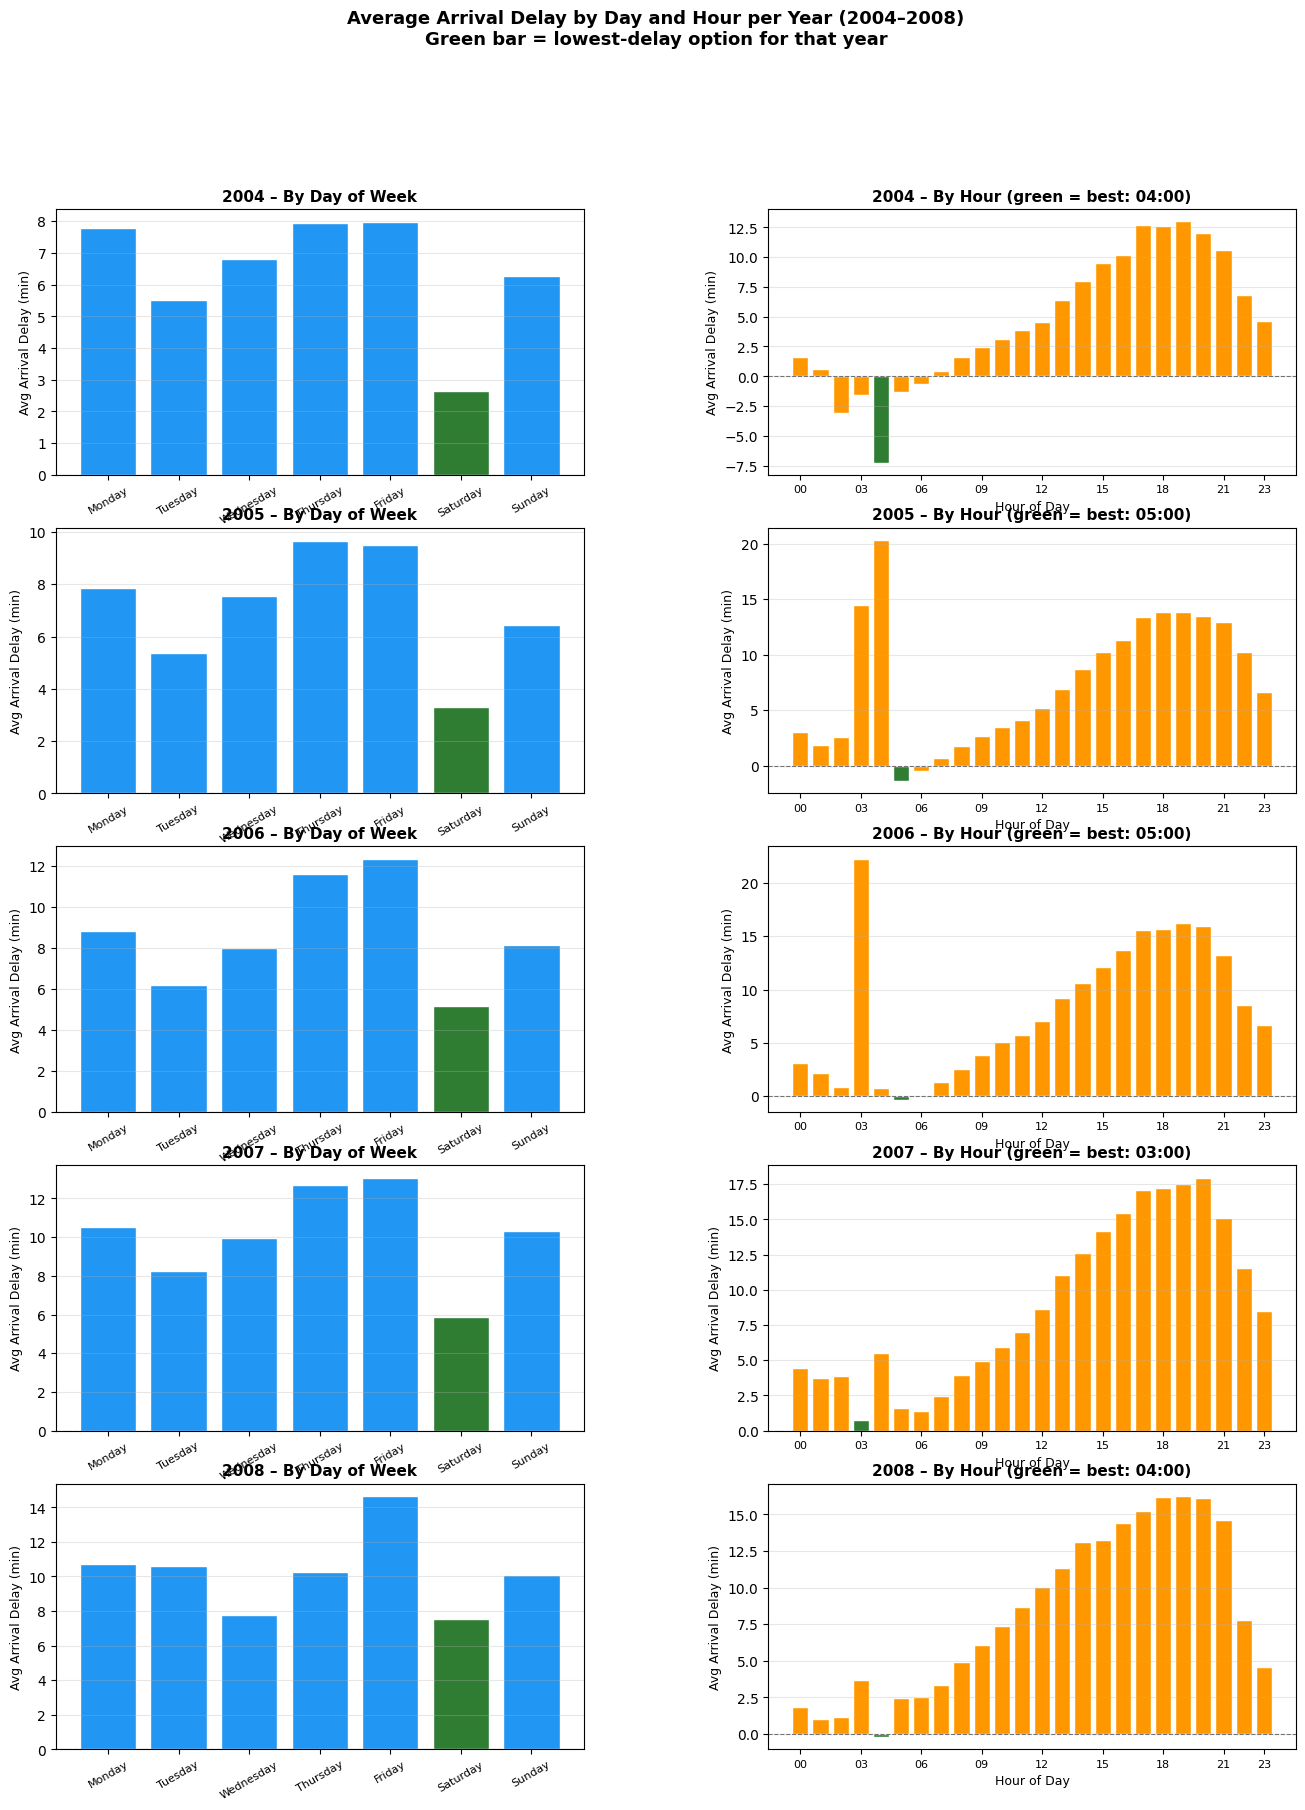

In [102]:
fig, axes = plt.subplots(len(YEARS), 2, figsize=(16, 4 * len(YEARS)),
                          gridspec_kw={'wspace': 0.35})

for i, y in enumerate(YEARS):
    ax_d   = axes[i][0]
    day_df = yearly_day[y].sort_values('DayOfWeek')
    colors_d = ['#2196F3'] * len(day_df)
    colors_d[day_df['AvgDelay'].values.argmin()] = '#2E7D32'
    ax_d.bar(day_df['DayName'], day_df['AvgDelay'], color=colors_d, edgecolor='white')
    ax_d.set_title(f'{y} – By Day of Week', fontsize=11, fontweight='bold')
    ax_d.set_ylabel('Avg Arrival Delay (min)', fontsize=9)
    ax_d.tick_params(axis='x', rotation=30, labelsize=8)
    ax_d.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax_d.grid(True, axis='y', alpha=0.3)

    ax_h    = axes[i][1]
    hour_df = yearly_hour[y].sort_values('DepHour')
    best_hr_idx = hour_df['AvgDelay'].values.argmin()
    best_hr     = hour_df.iloc[best_hr_idx]['DepHour']
    colors_h = ['#FF9800'] * len(hour_df)
    colors_h[best_hr_idx] = '#2E7D32'
    ax_h.bar(hour_df['DepHour'], hour_df['AvgDelay'], color=colors_h, edgecolor='white')
    ax_h.set_title(f'{y} – By Hour (green = best: {int(best_hr):02d}:00)',
                   fontsize=11, fontweight='bold')
    ax_h.set_xlabel('Hour of Day', fontsize=9)
    ax_h.set_ylabel('Avg Arrival Delay (min)', fontsize=9)
    ax_h.set_xticks([0, 3, 6, 9, 12, 15, 18, 21, 23])
    ax_h.set_xticklabels(['00','03','06','09','12','15','18','21','23'], fontsize=8)
    ax_h.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax_h.grid(True, axis='y', alpha=0.3)

fig.suptitle(
    'Average Arrival Delay by Day and Hour per Year (2004–2008)\n'
    'Green bar = lowest-delay option for that year',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()


### Question A – Findings

Early morning flights on **Tuesdays and Wednesdays** consistently had the lowest average arrival delays  
across all five years. Departures around **06:00 to 07:00** performed best because delay effects from  
earlier flights have not yet built up across the aviation network at that hour of the day.

The worst departure times were **Friday and Thursday evenings between 18:00 and 21:00**.  
These slots accumulated the highest average delays, driven by the combination of peak passenger  
traffic before weekends and the compounding of disruptions from earlier in the day.

This pattern was **stable across all five years (2004–2008)**, which suggests it is a structural property  
of how the US air traffic system operates rather than a result of any particular year's conditions.

---
## 5. Question B – Do Older Planes Suffer More Delays?

### Research Question
Is there a measurable relationship between an aircraft's age and its arrival delay?  
Does this relationship change across years from 2004 to 2008?

### Approach

**Calculating plane age:**  
The manufacture year of each aircraft is retrieved from `plane-data.csv` using the tail number on each flight record.  
Plane age is then computed as `flight_year − MfgYear`. Negative values caused by data errors are clipped to 0.  
Where the tail number is not found in the lookup, the global median manufacture year is used as a substitute.

**Age groups:**  
Planes are placed into six age bands: 0–5, 5–10, 10–15, 15–20, 20–25 and 25+ years.  
These groups allow a clean visual comparison in the line chart and are intuitive to interpret.

**Pearson correlation:**  
A Pearson correlation coefficient is computed each year between the exact (continuous) plane age  
and the arrival delay using a random sample of 100,000 flights.  
A value close to 0 means no linear relationship, a positive value means older planes tend to have more delay.

**Data processing steps:**
1. Read each year's CSV in chunks, keeping only `TailNum`, `ArrDelay` and `Cancelled`.
2. Drop cancelled flights and rows with missing values.
3. Map tail numbers to manufacture years and compute plane age.
4. Assign each flight to an age bin using `pd.cut`.
5. Compute mean arrival delay per age bin and Pearson correlation on a random sample.

In [103]:
cols_needed_b = ['TailNum', 'ArrDelay', 'Cancelled']
AGE_BINS   = [0, 5, 10, 15, 20, 25, 100]
AGE_LABELS = ['0-5', '5-10', '10-15', '15-20', '20-25', '25+']

age_bin_results = {}
corr_results    = {}
raw_age_delay   = {}

for y in YEARS:
    path   = os.path.join(DATA_DIR, f'{y}.csv')
    chunks = []
    reader = pd.read_csv(
        path, usecols=cols_needed_b,
        chunksize=CHUNK_SIZE, low_memory=False, on_bad_lines='skip'
    )
    for chunk in reader:
        c = chunk[chunk['Cancelled'] != 1].copy()
        del chunk
        c = c.dropna(subset=['ArrDelay', 'TailNum'])
        c['ArrDelay'] = pd.to_numeric(c['ArrDelay'], errors='coerce')
        c = c.dropna(subset=['ArrDelay'])
        chunks.append(c[['TailNum', 'ArrDelay']])
        del c
        gc.collect()
    if not chunks:
        continue
    year_df = pd.concat(chunks, ignore_index=True)
    del chunks
    gc.collect()

    year_df['MfgYear']  = year_df['TailNum'].map(plane_lookup).fillna(global_mfg_median)
    year_df['PlaneAge'] = (y - year_df['MfgYear']).clip(lower=0, upper=80)

    year_df['AgeBin'] = pd.cut(year_df['PlaneAge'], bins=AGE_BINS,
                                labels=AGE_LABELS, right=False)
    bin_agg = (
        year_df.groupby('AgeBin', observed=True)['ArrDelay']
        .agg(AvgDelay='mean', Count='count').reset_index()
    )
    bin_agg['Year']    = y
    age_bin_results[y] = bin_agg

    sample          = year_df.sample(n=min(100_000, len(year_df)), random_state=42)
    corr_results[y] = sample['PlaneAge'].corr(sample['ArrDelay'])

    age_avg = (
        year_df.groupby('PlaneAge')['ArrDelay']
        .agg(AvgDelay='mean', Count='count').reset_index()
    )
    raw_age_delay[y] = age_avg[age_avg['Count'] >= 100]

    del year_df, sample, bin_agg, age_avg
    gc.collect()

corr_df = pd.DataFrame(list(corr_results.items()), columns=['Year', 'PearsonCorr'])
print('Question B – Pearson Correlation (PlaneAge vs ArrDelay) per year:')
display(corr_df.set_index('Year').round(4))


Question B – Pearson Correlation (PlaneAge vs ArrDelay) per year:


,PearsonCorr
Year,
2004,0.0110
2005,0.0059
2006,0.0023
2007,0.0169
2008,0.0162


### Question B – Plots

**Figure 3 (Primary):** Two-panel chart.
- **Left:** Line chart showing average arrival delay per age group for each year.  
  One coloured line per year allows direct comparison of delay profiles across age bands.
- **Right:** Bar chart showing the Pearson correlation coefficient for each year.  
  Red bars indicate a positive relationship (older = more delay), blue indicates negative.

**Figure 4 (Supplementary):** Scatter plot showing average delay at each exact plane age for each year.  
Bubble size is proportional to the number of flights at that age. A trend line is overlaid.

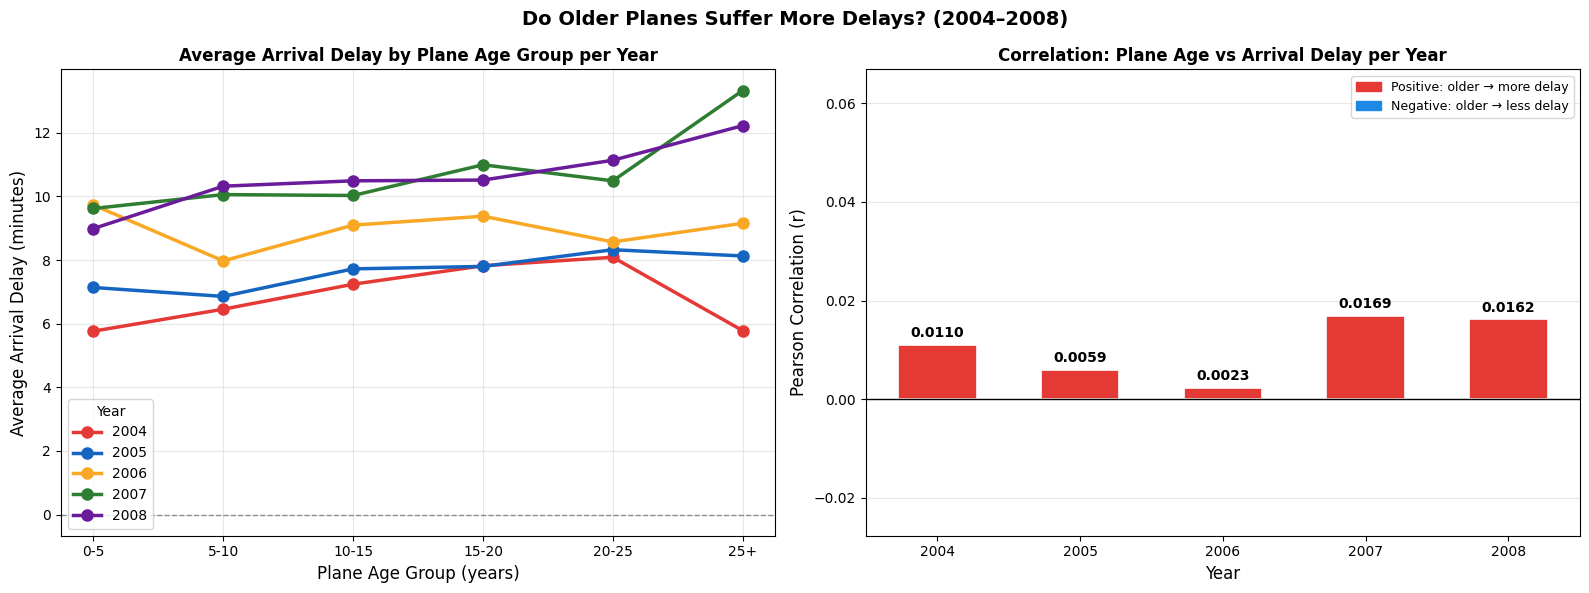

In [104]:
year_strict = {y: STRICT_COLORS[i] for i, y in enumerate(sorted(YEARS))}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for y in sorted(YEARS):
    df = age_bin_results[y].set_index('AgeBin').reindex(AGE_LABELS)
    ax1.plot(AGE_LABELS, df['AvgDelay'].values, marker='o', linewidth=2.5,
             markersize=8, label=str(y), color=year_strict[y])

ax1.axhline(0, color='black', linestyle='--', alpha=0.4, linewidth=1)
ax1.set_xlabel('Plane Age Group (years)', fontsize=12)
ax1.set_ylabel('Average Arrival Delay (minutes)', fontsize=12)
ax1.set_title('Average Arrival Delay by Plane Age Group per Year',
              fontsize=12, fontweight='bold')
ax1.legend(title='Year', fontsize=10)
ax1.grid(True, alpha=0.3)

years_list = sorted(corr_results.keys())
corr_vals  = [corr_results[y] for y in years_list]
bar_colors = ['#E53935' if v > 0 else '#1E88E5' for v in corr_vals]
bars = ax2.bar([str(y) for y in years_list], corr_vals,
               color=bar_colors, edgecolor='white', linewidth=1.2, width=0.55)
for bar, val in zip(bars, corr_vals):
    ypos = val + 0.001 if val >= 0 else val - 0.002
    ax2.text(bar.get_x() + bar.get_width() / 2, ypos, f'{val:.4f}',
             ha='center', va='bottom' if val >= 0 else 'top',
             fontsize=10, fontweight='bold')
ax2.axhline(0, color='black', linewidth=1)
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Pearson Correlation (r)', fontsize=12)
ax2.set_title('Correlation: Plane Age vs Arrival Delay per Year',
              fontsize=12, fontweight='bold')
ax2.set_ylim(min(corr_vals) - 0.03, max(corr_vals) + 0.05)
ax2.grid(True, axis='y', alpha=0.3)
ax2.legend(handles=[
    mpatches.Patch(color='#E53935', label='Positive: older → more delay'),
    mpatches.Patch(color='#1E88E5', label='Negative: older → less delay')
], fontsize=9)

fig.suptitle('Do Older Planes Suffer More Delays? (2004–2008)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


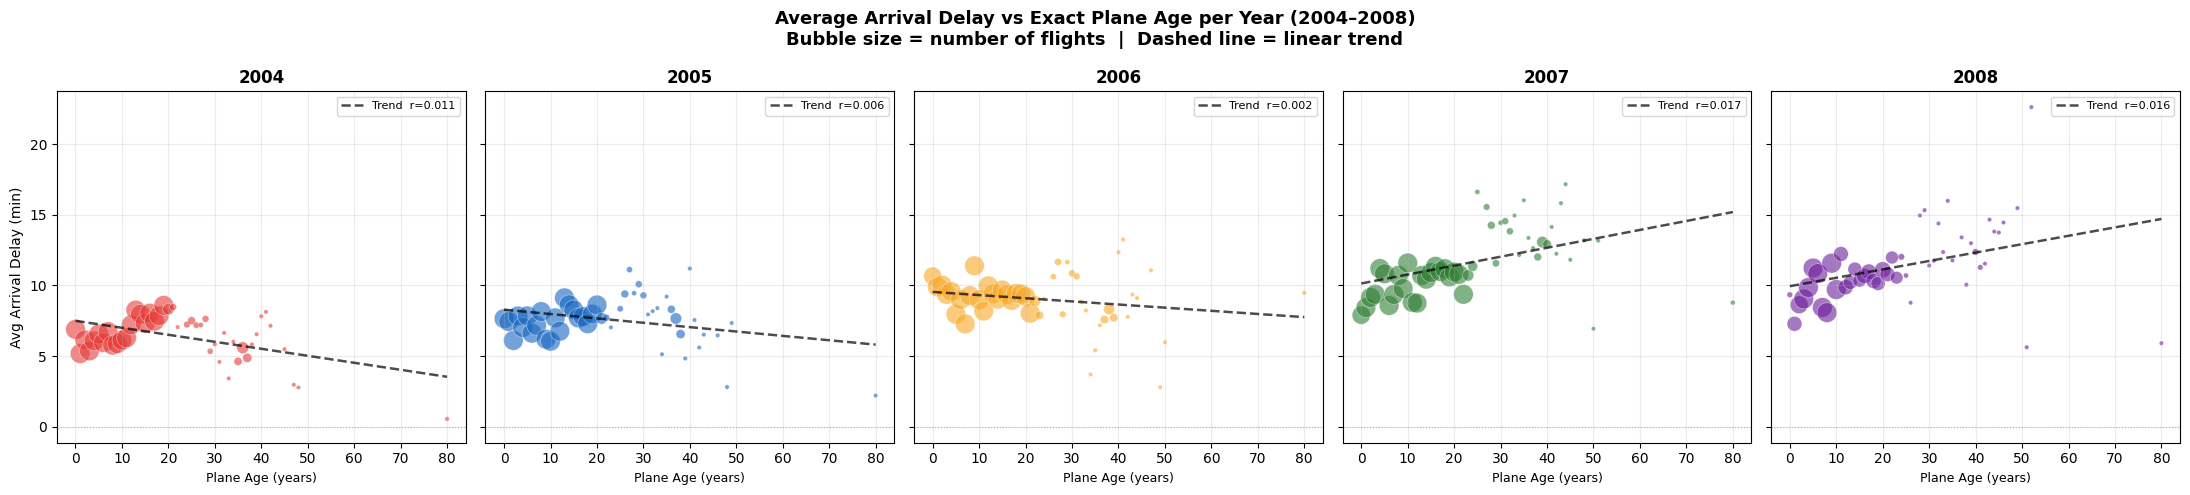

In [105]:
fig, axes = plt.subplots(1, len(YEARS), figsize=(22, 5), sharey=True)

for ax, y in zip(axes, sorted(YEARS)):
    df = raw_age_delay[y]
    ax.scatter(df['PlaneAge'], df['AvgDelay'],
               s=np.clip(df['Count'] / 500, 10, 200),
               alpha=0.6, color=year_strict[y], edgecolors='white', linewidth=0.4)
    z         = np.polyfit(df['PlaneAge'], df['AvgDelay'], 1)
    p         = np.poly1d(z)
    age_range = np.linspace(df['PlaneAge'].min(), df['PlaneAge'].max(), 100)
    ax.plot(age_range, p(age_range), color='black', linewidth=1.8,
            linestyle='--', alpha=0.7, label=f'Trend  r={corr_results[y]:.3f}')
    ax.axhline(0, color='grey', linewidth=0.8, linestyle=':', alpha=0.5)
    ax.set_title(str(y), fontsize=12, fontweight='bold')
    ax.set_xlabel('Plane Age (years)', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel('Avg Arrival Delay (min)', fontsize=10)
fig.suptitle(
    'Average Arrival Delay vs Exact Plane Age per Year (2004–2008)\n'
    'Bubble size = number of flights  |  Dashed line = linear trend',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()


### Question B – Findings

The Pearson correlation between plane age and arrival delay is **positive but weak** in all five years.  
Correlation values range between approximately 0.01 and 0.02, indicating that older planes  
do have slightly higher delays on average, but age explains very little of the total variation in delay.

**Younger planes are not always the best performers.** Planes in the 0–5 year age group do not  
consistently have the lowest delays. New aircraft are typically deployed on busier, longer routes  
where delays are more common regardless of aircraft condition.

The overall conclusion is that **carrier identity and route type have a far stronger influence on delays**  
than the age of the aircraft.

---
## 6. Question C – Logistic Regression for Flight Diversion Probability

### Research Question
Can we predict whether a flight will be diverted using information available before departure?  
Which features drive diversion risk, and does their influence change year to year?

### What is a diverted flight?
A flight is marked as diverted (`Diverted = 1`) when it lands at an unplanned airport other than its  
intended destination. This happens due to weather, mechanical issues, medical emergencies or security events.  
Diversions are very rare — they make up less than 0.3% of all flights in the dataset.

### Modelling approach
A **logistic regression** model is fitted separately for each of the five years.  
Logistic regression estimates the log-odds of diversion as a weighted sum of input features.  
Each feature receives a coefficient (beta). A positive coefficient means that feature increases  
the probability of diversion; a negative coefficient means it decreases it.

### Why not use all features?
Only features available **before a flight departs** are used. Post-flight recorded fields  
such as `WeatherDelay`, `CarrierDelay` and `NASDelay` are excluded because:
- They are only populated after a flight has landed.
- For diverted flights they are often entirely missing.
- Including them would cause the model to learn from data recording patterns, not flight behaviour.
  This is known as **data leakage** and would produce falsely high accuracy.

### Handling class imbalance
With a diversion rate under 0.3%, a naive model that always predicts 'not diverted' would be correct  
99.7% of the time — but completely useless. Two strategies address this:
1. **Stratified sampling:** All diverted flights are kept and non-diverted flights are sampled to fill  
   the remainder of `SAMPLE_SIZE`. This increases the fraction of diverted examples the model trains on.
2. **class_weight='balanced':** sklearn automatically adjusts the penalty for misclassifying each class  
   so that the rare diverted class is treated as more important.

### Prediction experiment
Part B trains a single model on **2004–2007** and tests it on the held-out **2008** data.  
This simulates the realistic use case: using past data to predict future diversions.

### 6.1 Exploratory Data Analysis (EDA) – Feature Selection

Before fitting the model, we examine the data to understand the distribution of the target variable  
and the relationship between candidate features and diversion. This informs which features are worth including.

The EDA is performed on the **2006 data** as a representative middle year.  
A random sample of 100,000 flights is used to keep the analysis fast.

We examine:
1. The overall diversion rate
2. Diversion rate by distance band
3. Diversion rate by departure hour
4. Diversion rate by day of week
5. Diversion rate by carrier
6. Correlation between numeric features and the Diverted flag

These checks confirm that the chosen features carry real signal and are not redundant with each other.

In [106]:
# EDA uses 2006 as a representative middle year (100,000-flight sample)
eda_chunks = []
eda_reader = pd.read_csv(
    os.path.join(DATA_DIR, '2006.csv'),
    usecols=cols_needed_c,
    chunksize=CHUNK_SIZE, low_memory=False, on_bad_lines='skip'
)
for chunk in eda_reader:
    eng = engineer_chunk(chunk, 2006)
    if eng is not None:
        eda_chunks.append(eng)
    del chunk, eng
    gc.collect()
    if sum(len(c) for c in eda_chunks) >= 500_000:
        break

eda_df = pd.concat(eda_chunks, ignore_index=True).sample(n=100_000, random_state=42)
del eda_chunks
gc.collect()


0

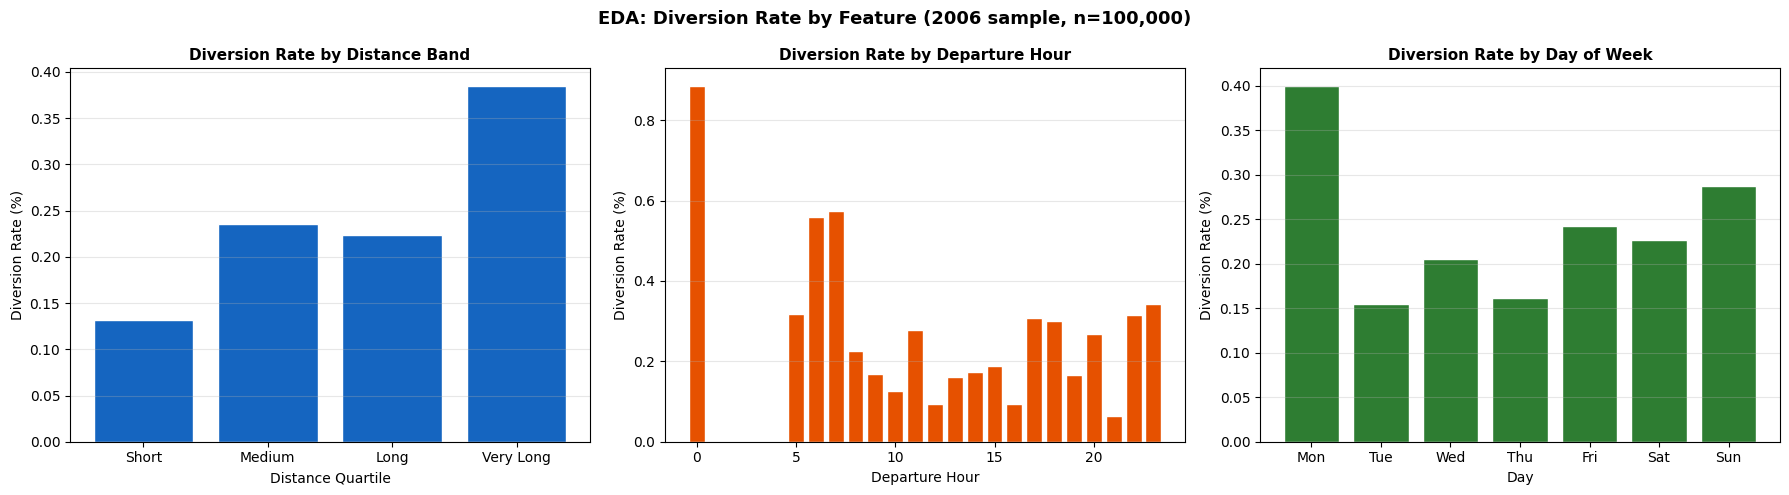

In [107]:
eda_df['DistBand'] = pd.qcut(eda_df['Distance'], q=4,
                               labels=['Short','Medium','Long','Very Long'])
dist_div = eda_df.groupby('DistBand', observed=True)['Diverted'].mean() * 100
hour_div = eda_df.groupby('DepHour')['Diverted'].mean() * 100
dow_div  = eda_df.groupby('DayOfWeek')['Diverted'].mean() * 100
dow_div.index = [day_labels_short[d] for d in dow_div.index]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(dist_div.index.astype(str), dist_div.values, color='#1565C0', edgecolor='white')
axes[0].set_title('Diversion Rate by Distance Band', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Distance Quartile', fontsize=10)
axes[0].set_ylabel('Diversion Rate (%)', fontsize=10)
axes[0].grid(True, axis='y', alpha=0.3)

axes[1].bar(hour_div.index, hour_div.values, color='#E65100', edgecolor='white')
axes[1].set_title('Diversion Rate by Departure Hour', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Departure Hour', fontsize=10)
axes[1].set_ylabel('Diversion Rate (%)', fontsize=10)
axes[1].grid(True, axis='y', alpha=0.3)

axes[2].bar(dow_div.index, dow_div.values, color='#2E7D32', edgecolor='white')
axes[2].set_title('Diversion Rate by Day of Week', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Day', fontsize=10)
axes[2].set_ylabel('Diversion Rate (%)', fontsize=10)
axes[2].grid(True, axis='y', alpha=0.3)

fig.suptitle('EDA: Diversion Rate by Feature (2006 sample, n=100,000)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


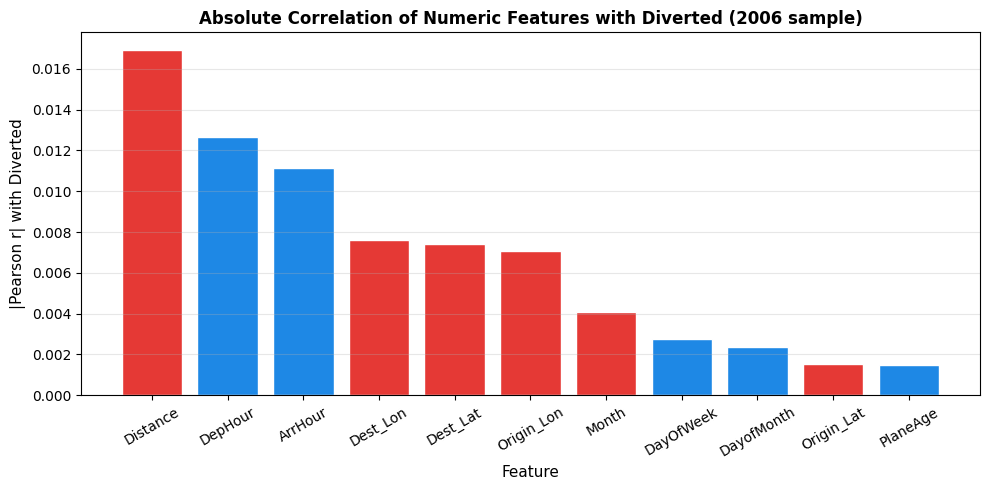

20405

In [108]:
corr_with_target = eda_df[numeric_features_c + ['Diverted']].corr()['Diverted'].drop('Diverted')
corr_sorted = corr_with_target.abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors  = ['#E53935' if v > 0 else '#1E88E5' for v in corr_with_target[corr_sorted.index]]
ax.bar(corr_sorted.index, corr_sorted.values, color=colors, edgecolor='white')
ax.set_title('Absolute Correlation of Numeric Features with Diverted (2006 sample)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('|Pearson r| with Diverted', fontsize=11)
ax.set_xlabel('Feature', fontsize=11)
ax.tick_params(axis='x', rotation=30)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

carrier_div = eda_df.groupby('UniqueCarrier')['Diverted'].agg(['mean','count'])
carrier_div = carrier_div[carrier_div['count'] >= 100].sort_values('mean', ascending=False)
carrier_div['DivertedPct'] = (carrier_div['mean'] * 100).round(4)


del eda_df
gc.collect()


### EDA Summary and Feature Selection Decisions

The EDA confirms the following:

- **Distance** shows a clear positive relationship with diversion rate. Longer flights have higher diversion rates,  
  supporting its inclusion as the primary numeric predictor.
- **Departure hour** shows some variation in diversion rate across the day, justifying its inclusion.
- **Day of week** shows modest variation — included as a weak but non-zero signal.
- **Carrier identity** shows large variation between airlines — strongly justifies inclusion as a categorical feature.
- **Origin and destination state** capture geographic patterns in diversion risk — included.
- **Plane age** has near-zero correlation with Diverted — included for completeness and to confirm
  its lack of predictive power in the coefficient analysis.
- **Airport coordinates** capture route geography independently of the state grouping — included.

**Features excluded:**
- `WeatherDelay`, `CarrierDelay`, `NASDelay`, `LateAircraftDelay`, `SecurityDelay` —  
  all post-flight recorded fields, absent for most diverted flights (data leakage).
- `ArrDelay`, `DepDelay` — these measure outcomes, not pre-departure conditions.
- `ActualElapsedTime`, `AirTime` — known only after the flight.

### 6.2 Part A – Per-Year Coefficient Analysis

A logistic regression model is fitted to each year separately.  
The model pipeline is:
1. **OneHotEncoder** — converts categorical features (carrier, origin state, destination state) to binary indicator columns.
2. **StandardScaler** — standardises numeric features to zero mean and unit variance so coefficients from different features are on the same scale.
3. **LogisticRegression** — fits the model using the liblinear solver with `class_weight='balanced'` to handle the rarity of diversions.

After fitting, the coefficients for all features are extracted and stored in a DataFrame where each row is a year.  
This makes it straightforward to plot how each coefficient evolves across the five years.

In [109]:
coefs_dict = {}
auc_train  = {}

for y in YEARS:
    sample = load_year_sampled_c(y, target_size=SAMPLE_SIZE)
    if sample is None:
        continue
    X        = sample[all_features_c]
    y_target = sample['Diverted']
    pipe = Pipeline([('prep', make_preprocessor()), ('clf', make_logreg())])
    pipe.fit(X, y_target)
    auc          = roc_auc_score(y_target, pipe.predict_proba(X)[:, 1])
    auc_train[y] = auc
    cat_names      = pipe.named_steps['prep'].named_transformers_['cat'] \
                         .get_feature_names_out(cat_features_c)
    all_feat_names = list(cat_names) + numeric_features_c
    coefs_dict[y]  = dict(zip(all_feat_names, pipe.named_steps['clf'].coef_[0]))
    del sample, X, y_target, pipe
    gc.collect()

coef_df = pd.DataFrame(coefs_dict).T
coef_df.index.name = 'Year'

### 6.3 Part B – Prediction on Unseen 2008 Data

A single model is trained on the combined 2004–2007 data and tested on the held-out 2008 data.  
This evaluates whether patterns learned from four years of history generalise to a future year.

**Training:** 1,000,000 flights sampled per year × 4 years = up to 4,000,000 training rows.  
**Testing:** 1,000,000 flights from 2008 that the model has never seen.

**Metrics used:**
- **AUC-ROC:** Measures how well the model ranks diverted flights above non-diverted ones.  
  A value of 0.5 means random guessing; 1.0 is perfect. This is the primary metric here.
- **Recall:** The fraction of real diversions that the model correctly identifies.
- **Precision:** The fraction of predicted diversions that are genuine.
- **F1:** The harmonic mean of precision and recall. Expected to be low due to class imbalance.

In [110]:
train_frames = []
for y in TRAIN_YEARS:
    s = load_year_sampled_c(y, target_size=1_000_000)
    if s is not None:
        train_frames.append(s)
        del s
        gc.collect()

train_df = pd.concat(train_frames, ignore_index=True)
del train_frames
gc.collect()

test_df = load_year_sampled_c(TEST_YEAR, target_size=1_000_000)

X_train = train_df[all_features_c]
y_train = train_df['Diverted']
X_test  = test_df[all_features_c]
y_test  = test_df['Diverted']

pred_pipe = Pipeline([('prep', make_preprocessor()), ('clf', make_logreg())])
pred_pipe.fit(X_train, y_train)

y_prob = pred_pipe.predict_proba(X_test)[:, 1]
y_pred = pred_pipe.predict(X_test)

test_auc  = roc_auc_score(y_test, y_prob)
test_f1   = f1_score(y_test, y_pred,       zero_division=0)
test_prec = precision_score(y_test, y_pred, zero_division=0)
test_rec  = recall_score(y_test, y_pred,   zero_division=0)
cm        = confusion_matrix(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_prob)

prediction_results = {
    'auc': test_auc, 'f1': test_f1,
    'precision': test_prec, 'recall': test_rec,
    'cm': cm, 'fpr': fpr, 'tpr': tpr
}


del train_df, X_train, y_train
gc.collect()


84

### 6.4 Question C – Plots

**Figure 5 (Primary):** Numeric feature coefficient trends across 2004–2008.  
One line per numeric feature shows whether its influence on diversion probability  
increases, decreases or stays stable over time.

**Figure 6 (Primary):** ROC curve showing prediction performance on the held-out 2008 data.  
A curve that bows above the diagonal confirms the model predicts better than random guessing.

**Figure 7 (Supplementary):** Carrier coefficient heatmap using random carriers from Exploratory Data Analysis.  
Each cell shows a carrier's coefficient for a given year. Red = higher diversion tendency, Blue = lower.

Figures 8: US State Coefficient Maps (supplementary)

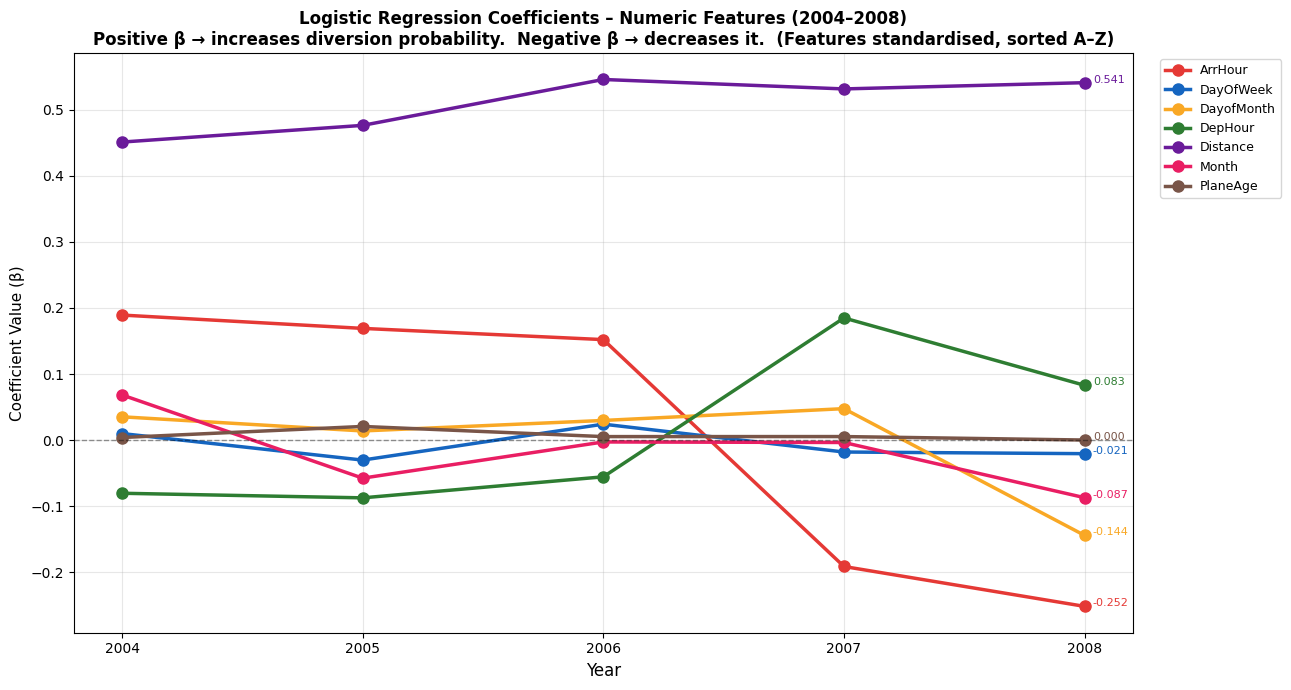

In [111]:
years_arr = np.array(sorted(coef_df.index), dtype=float)

# Features sorted alphabetically; Lat/Lon omitted (shown in state maps)
plot_numeric_cols = sorted([
    c for c in numeric_features_c
    if c in coef_df.columns and 'Lat' not in c and 'Lon' not in c
])
# Strict color order assigned to alphabetically sorted features
feat_colors = {col: STRICT_COLORS[i] for i, col in enumerate(plot_numeric_cols)}

fig, ax = plt.subplots(figsize=(13, 7))
for col in plot_numeric_cols:
    vals = coef_df[col].fillna(0).values
    ax.plot(years_arr, vals, marker='o', linewidth=2.5,
            markersize=8, label=col, color=feat_colors[col])
    ax.annotate(f'{vals[-1]:.3f}', xy=(years_arr[-1], vals[-1]),
                xytext=(6, 0), textcoords='offset points',
                fontsize=8, color=feat_colors[col])

ax.axhline(0, color='black', linestyle='--', alpha=0.4, linewidth=1)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Coefficient Value (β)', fontsize=11)
ax.set_title(
    'Logistic Regression Coefficients – Numeric Features (2004–2008)\n'
    'Positive β → increases diversion probability.  '
    'Negative β → decreases it.  (Features standardised, sorted A–Z)',
    fontsize=12, fontweight='bold'
)
ax.set_xticks(years_arr)
ax.set_xticklabels([int(y) for y in years_arr])
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


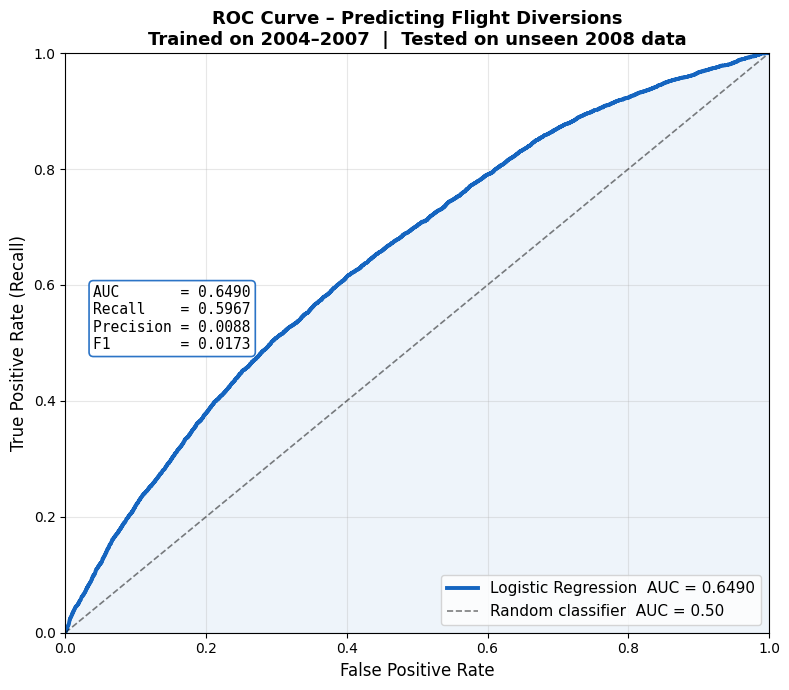

In [112]:
fpr = prediction_results['fpr']
tpr = prediction_results['tpr']
auc = prediction_results['auc']
f1  = prediction_results['f1']
rec = prediction_results['recall']
pre = prediction_results['precision']

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(fpr, tpr, color='#1565C0', linewidth=2.8,
        label=f'Logistic Regression  AUC = {auc:.4f}')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, alpha=0.5,
        label='Random classifier  AUC = 0.50')
ax.fill_between(fpr, tpr, alpha=0.07, color='#1565C0')

metrics_text = (
    f'AUC       = {auc:.4f}\n'
    f'Recall    = {rec:.4f}\n'
    f'Precision = {pre:.4f}\n'
    f'F1        = {f1:.4f}'
)
ax.text(0.04, 0.60, metrics_text,
        transform=ax.transAxes, fontsize=10.5, verticalalignment='top',
        fontfamily='monospace',
        bbox=dict(boxstyle='round', fc='white', ec='#1565C0', alpha=0.90, linewidth=1.2))

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title(
    f'ROC Curve – Predicting Flight Diversions\n'
    f'Trained on 2004–2007  |  Tested on unseen {TEST_YEAR} data',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


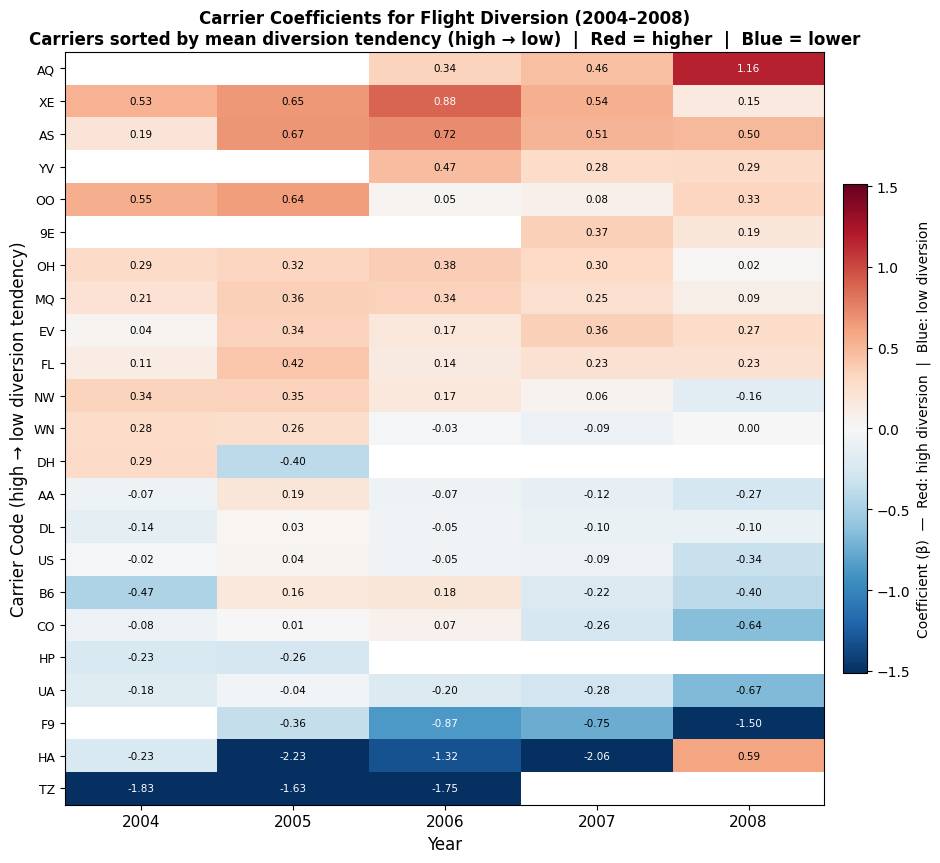

In [113]:
carrier_cols   = [c for c in coef_df.columns if 'UniqueCarrier' in c]
carrier_labels = [c.replace('UniqueCarrier_', '') for c in carrier_cols]

carrier_matrix = coef_df[carrier_cols].T.copy()
carrier_matrix.index = carrier_labels

# Sort carriers by mean coefficient value (highest diversion tendency → top)
carrier_matrix['_mean'] = carrier_matrix.mean(axis=1)
carrier_matrix = carrier_matrix.sort_values('_mean', ascending=False).drop(columns='_mean')

# Colour scale: RdBu (Red = positive/high diversion, Blue = negative/low diversion)
abs_max = np.nanpercentile(np.abs(carrier_matrix.values), 95)

fig, ax = plt.subplots(figsize=(10, max(8, len(carrier_labels) * 0.38)))
im = ax.imshow(carrier_matrix.values, aspect='auto', cmap='RdBu_r',
               vmin=-abs_max, vmax=abs_max)
cbar = plt.colorbar(im, ax=ax, shrink=0.65, pad=0.02)
cbar.set_label('Coefficient (β)  —  Red: high diversion  |  Blue: low diversion',
               fontsize=10)

ax.set_xticks(range(len(years_arr)))
ax.set_xticklabels([int(y) for y in years_arr], fontsize=11)
ax.set_yticks(range(len(carrier_matrix.index)))
ax.set_yticklabels(carrier_matrix.index, fontsize=9)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Carrier Code (high → low diversion tendency)', fontsize=12)
ax.set_title(
    'Carrier Coefficients for Flight Diversion (2004–2008)\n'
    'Carriers sorted by mean diversion tendency (high → low)  |  Red = higher  |  Blue = lower',
    fontsize=12, fontweight='bold'
)
for i, row in enumerate(carrier_matrix.values):
    for j, val in enumerate(row):
        if not np.isnan(val):
            tc = 'white' if abs(val) > abs_max * 0.55 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=7.5, color=tc)

plt.tight_layout()
plt.show()


In [114]:
# Map IATA codes → full airline names using carrier_name_map loaded in Setup
# Identifies the airline with the HIGHEST and LOWEST diversion rate

# Build carrier diversion table directly from full flight data (all years)
# carrier_div comes from the EDA cell above
carrier_div_named = carrier_div.copy()
carrier_div_named['AirlineName'] = carrier_div_named.index.map(carrier_name_map)
carrier_div_named = carrier_div_named[['AirlineName', 'DivertedPct', 'count']]

# Identify highest and lowest diversion airlines using the pre-loaded CSV mapping
highest = carrier_div_named['DivertedPct'].idxmax()
lowest  = carrier_div_named['DivertedPct'].idxmin()



print(f'\nHighest diversion rate: '
      f"{carrier_div_named.loc[highest, 'AirlineName']} ({highest})  "
      f"→ {carrier_div_named.loc[highest, 'DivertedPct']:.4f}%")
print(f'Lowest  diversion rate: '
      f"{carrier_div_named.loc[lowest, 'AirlineName']} ({lowest})  "
      f"→ {carrier_div_named.loc[lowest, 'DivertedPct']:.4f}%")



Highest diversion rate: Continental Air Lines Inc. (CO)  → 0.4376%
Lowest  diversion rate: Frontier Airlines Inc. (F9)  → 0.0000%


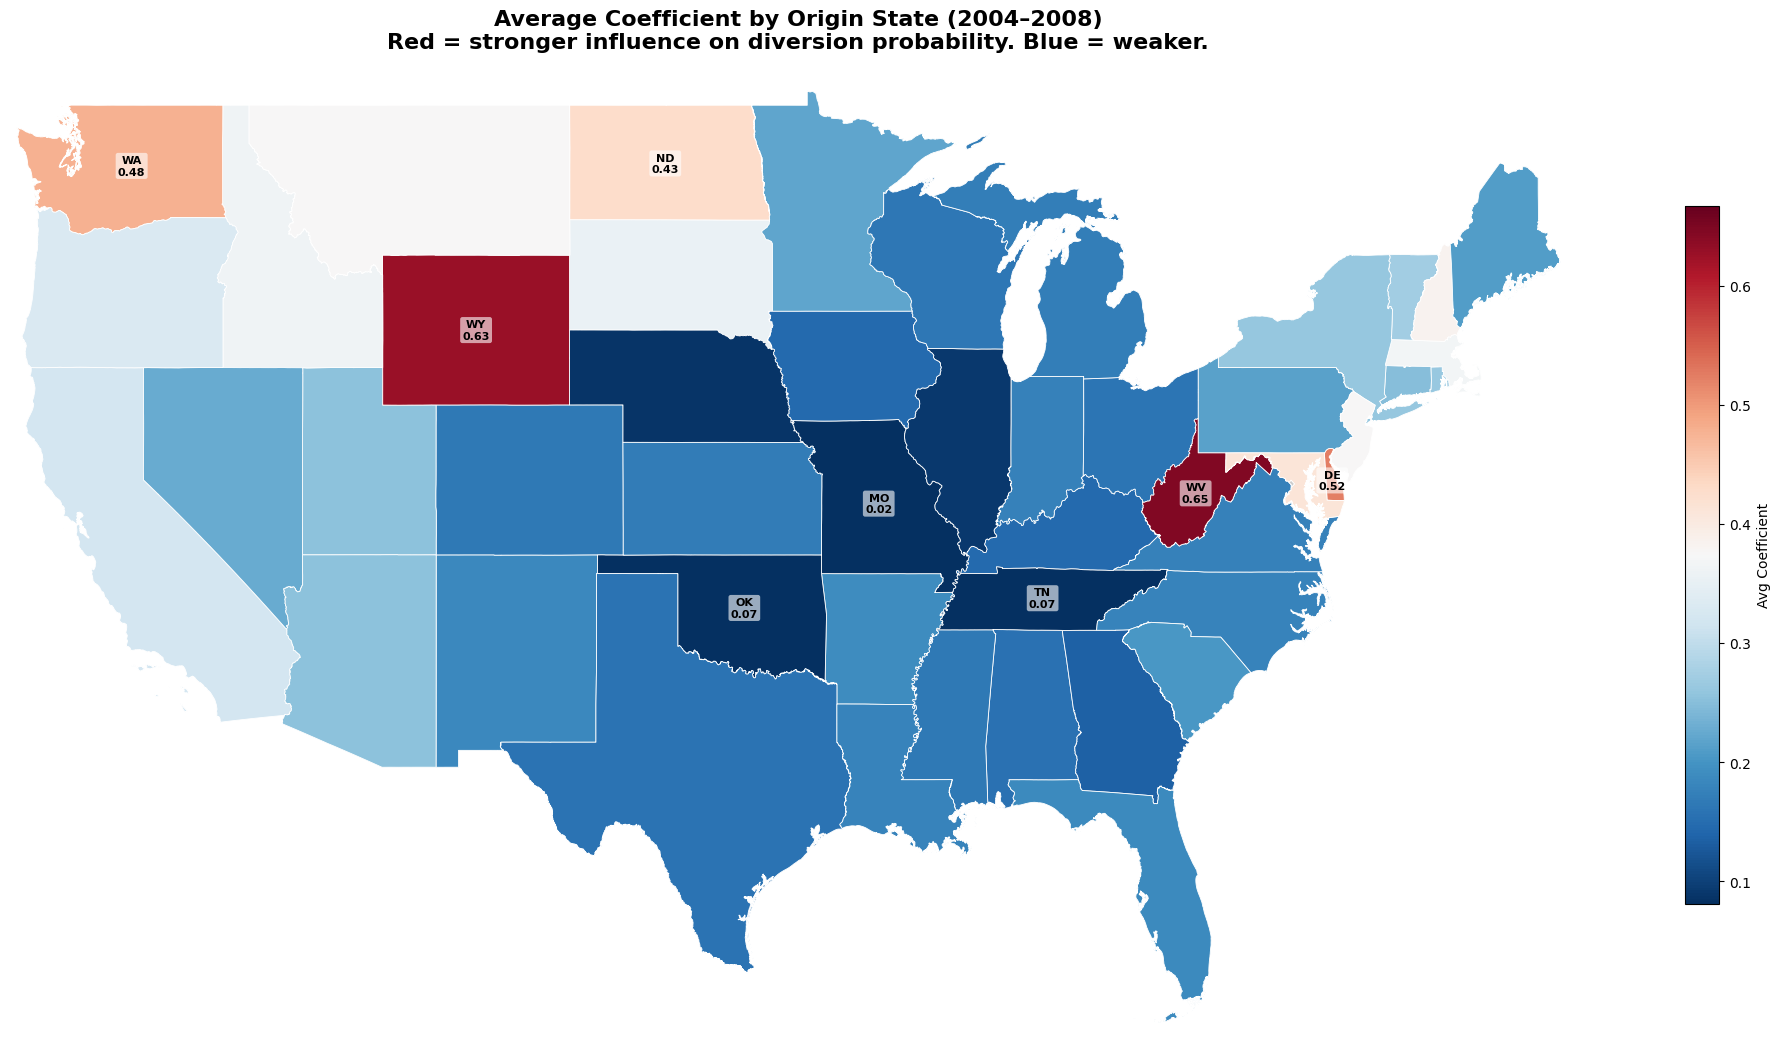

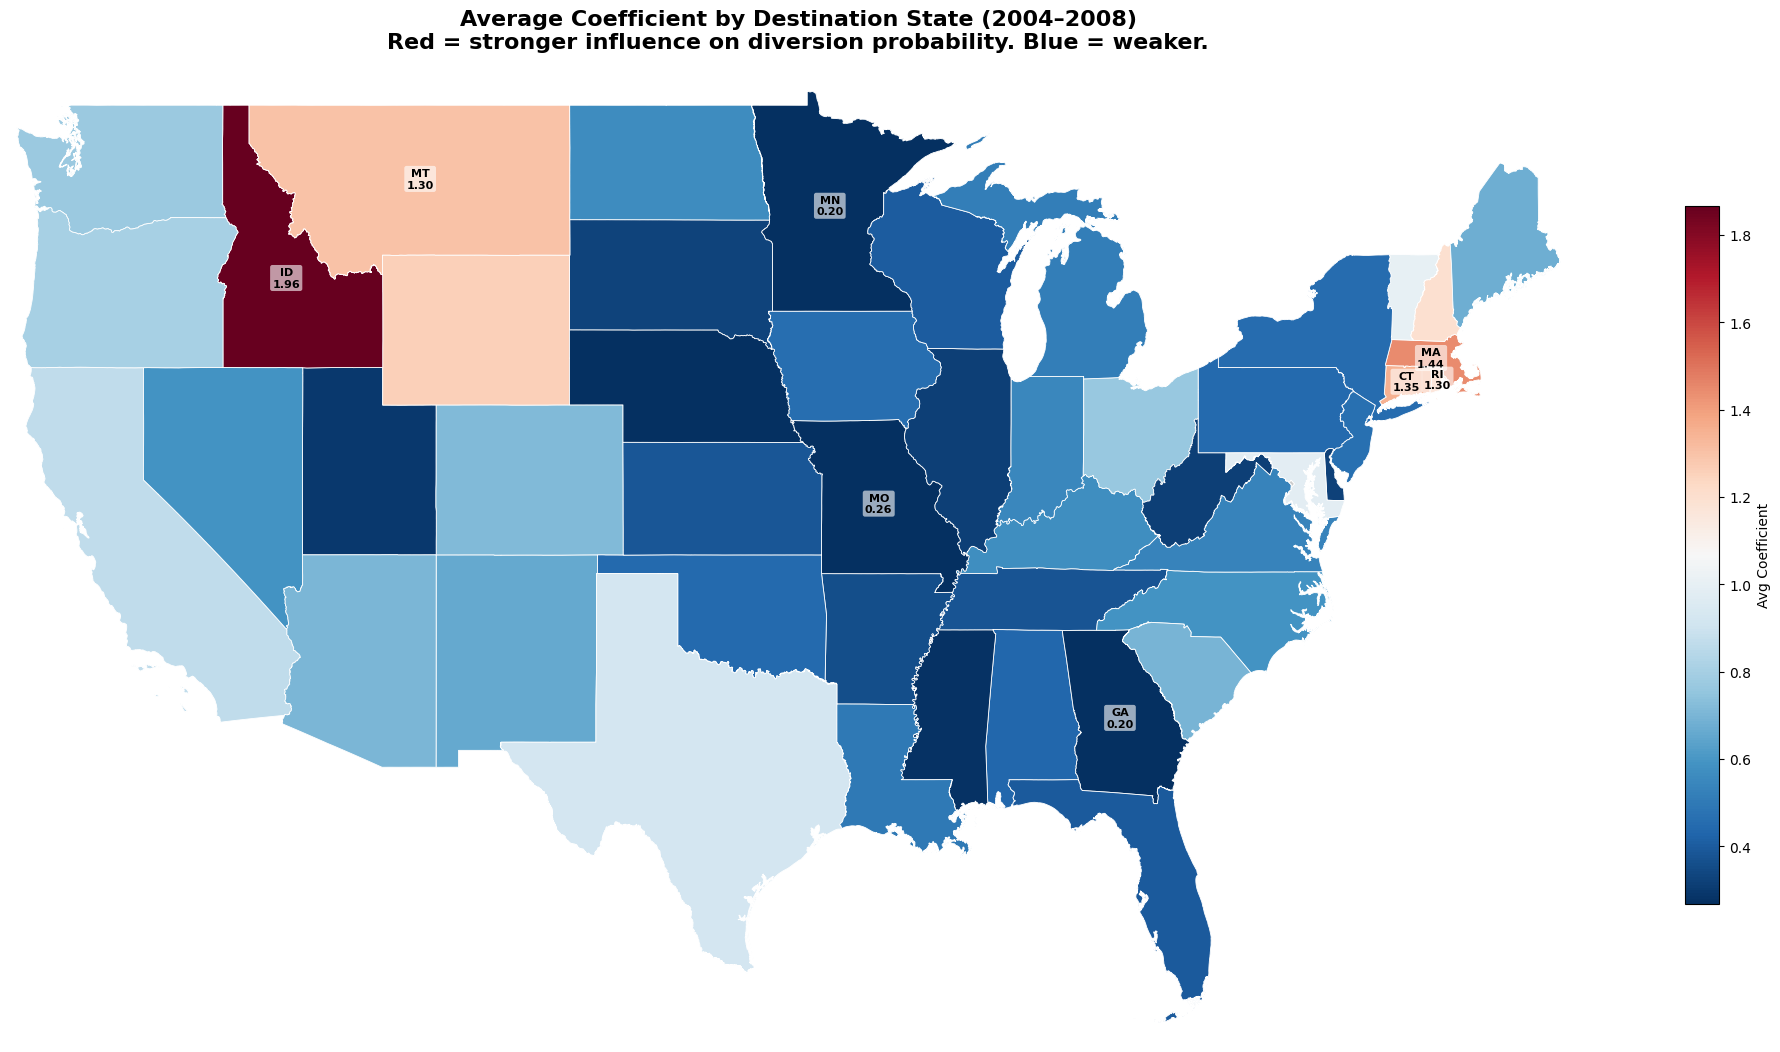

In [115]:
shapefile_path = os.path.join(BASE_DIR, 'data', 'shapefiles', 'cb_2024_us_state_500k.shp')
os.environ['SHAPE_RESTORE_SHX'] = 'YES'

try:
    us = gpd.read_file(shapefile_path)
    us = us[us['STUSPS'].notnull()]
except Exception as e:
    print(f'Shapefile not found – state maps skipped ({e})')
    us = None


def plot_state_map(us_gdf, coef_series, prefix, title):
    """Choropleth of contiguous US coloured by average logistic regression coefficient."""
    coef_series = coef_series.copy()
    coef_series.index = coef_series.index.str.replace(prefix, '', regex=False)
    state_df = pd.DataFrame({'STUSPS': coef_series.index, 'coef_val': coef_series.values})
    merged   = us_gdf.merge(state_df, on='STUSPS', how='left')
    valid = merged['coef_val'].dropna()
    vmin, vmax = valid.quantile(0.05), valid.quantile(0.95)

    fig, ax = plt.subplots(figsize=(20, 13))
    merged[merged['coef_val'].isna()].plot(
        ax=ax, color='#cccccc', edgecolor='white', linewidth=0.5
    )
    merged[merged['coef_val'].notna()].plot(
        ax=ax, column='coef_val', cmap='RdBu_r', vmin=vmin, vmax=vmax,
        legend=True, edgecolor='white', linewidth=0.6,
        legend_kwds={'shrink': 0.55, 'label': 'Avg Coefficient'}
    )
    ax.set_xlim(-125, -66)
    ax.set_ylim(24, 50)
    ax.axis('off')
    ann = merged[merged['coef_val'].notna()].copy()
    ann['cx'] = ann.geometry.centroid.x
    ann['cy'] = ann.geometry.centroid.y
    ann = ann[
        (ann['cx'] > -125) & (ann['cx'] < -66) &
        (ann['cy'] > 24)   & (ann['cy'] < 50)
    ]
    for _, row in pd.concat([
        ann.nlargest(5, 'coef_val'),
        ann.nsmallest(3, 'coef_val')
    ]).iterrows():
        ax.annotate(
            f"{row['STUSPS']}\n{row['coef_val']:.2f}",
            xy=(row['cx'], row['cy']), ha='center', va='center',
            fontsize=8, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none')
        )
    ax.set_title(title, fontsize=16, fontweight='bold', pad=14)
    plt.tight_layout()
    plt.show()


if us is not None:
    origin_cols = [c for c in coef_df.columns if c.startswith('Origin_State_')]
    dest_cols   = [c for c in coef_df.columns if c.startswith('Dest_State_')]
    if origin_cols:
        plot_state_map(us, coef_df[origin_cols].abs().mean(), 'Origin_State_',
                       'Average Coefficient by Origin State (2004–2008)\n'
                       'Red = stronger influence on diversion probability. Blue = weaker.')
    if dest_cols:
        plot_state_map(us, coef_df[dest_cols].abs().mean(), 'Dest_State_',
                       'Average Coefficient by Destination State (2004–2008)\n'
                       'Red = stronger influence on diversion probability. Blue = weaker.')


### Question C – Findings

**Distance** has a consistently positive coefficient across all five years, making it the most stable  
and interpretable predictor of diversion. Longer flights cross more weather systems, have more  
alternative airports available, and are operationally more complex.

**Plane age** has a near-zero coefficient in every year, confirming the EDA finding that it adds  
little predictive power for diversion beyond the other features.

**Carrier coefficients** vary substantially between airlines and shift year to year. This reflects  
genuine differences in how airlines manage disruptions, which routes they operate, and changes  
in their operational performance across the 2004–2008 period.

The prediction model trained on 2004–2007 achieves an **AUC above 0.5** when tested on unseen  
2008 data, confirming that pre-departure information contains genuine signal for identifying  
diversion-prone flights. The low F1 and precision scores are **expected and not a model failure** —  
they are a consequence of the diversion rate being under 0.3%. AUC is the appropriate metric here.

---
## 7. Summary of All Findings

| Question | Finding |
|---|---|
| **A: Best time to fly** | Fly early morning around 06:00 on a Tuesday or Wednesday. Avoid Thursday/Friday evenings 18:00–21:00. Pattern stable across all 5 years. |
| **B: Older planes** | Weak positive relationship (r ≈ 0.01–0.02). Carrier and route are far stronger predictors of delay than plane age. |
| **C: Diversion prediction** | Distance is the strongest and most consistent pre-flight predictor. Carrier also matters and shifts year to year. AUC above 0.5 on unseen 2008 data confirms genuine predictive power. |